<a href="https://colab.research.google.com/github/riyamotwanii/AML-Assignments/blob/main/Exp_9_AML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

========== DATASET ==========

     Outlook  Temp Humidity    Wind PlayTennis
0      Sunny   Hot     High    Weak         No
1      Sunny   Hot     High  Strong         No
2   Overcast   Hot     High    Weak        Yes
3       Rain  Mild     High    Weak        Yes
4       Rain  Cool   Normal    Weak        Yes
5       Rain  Cool   Normal  Strong         No
6   Overcast  Cool   Normal  Strong        Yes
7      Sunny  Mild     High    Weak         No
8      Sunny  Cool   Normal    Weak        Yes
9       Rain  Mild   Normal    Weak        Yes
10     Sunny  Mild   Normal  Strong        Yes
11  Overcast  Mild     High  Strong        Yes
12  Overcast   Hot   Normal    Weak        Yes
13      Rain  Mild     High  Strong         No

========== ENCODED DATASET ==========

    Outlook  Temp  Humidity  Wind  PlayTennis
0         2     1         0     1           0
1         2     1         0     0           0
2         0     1         0     1           1
3         1     2         0     1       

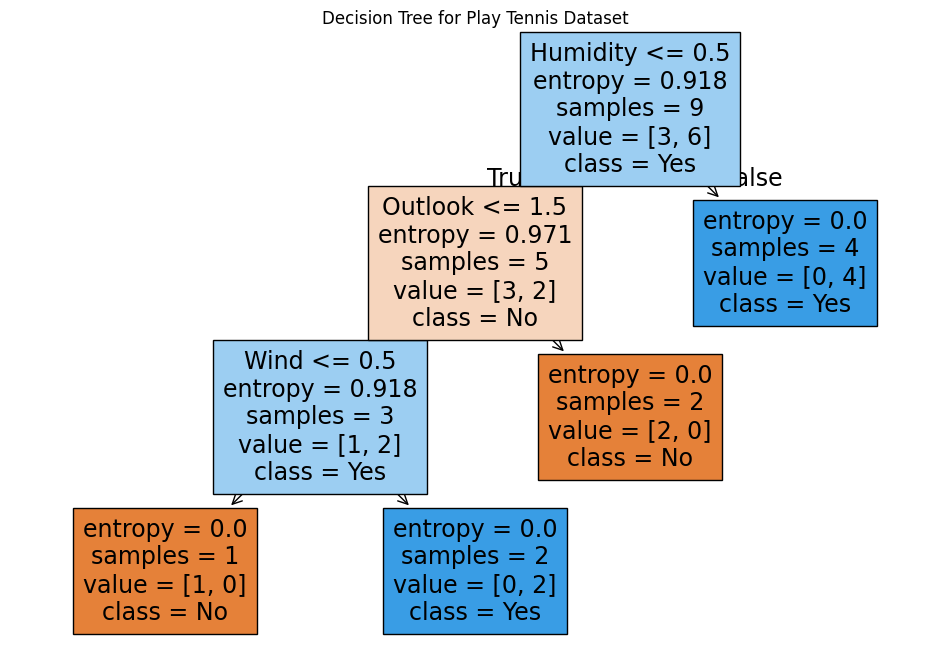


RESULT INTERPRETATION

1. Accuracy shows overall correctness of model.
2. Precision indicates how many predicted YES are correct.
3. Recall shows how many actual YES are identified.
4. F1-score balances precision and recall.
5. Decision Tree classifies Play Tennis based on weather conditions.


In [ ]:


import pandas as pd

from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt

# ============================================================
# STEP 2 : CREATE DATASET
# ============================================================

data = {
    'Outlook': [
        'Sunny', 'Sunny', 'Overcast', 'Rain',
        'Rain', 'Rain', 'Overcast', 'Sunny',
        'Sunny', 'Rain', 'Sunny', 'Overcast',
        'Overcast', 'Rain'
    ],

    'Temp': [
        'Hot', 'Hot', 'Hot', 'Mild',
        'Cool', 'Cool', 'Cool', 'Mild',
        'Cool', 'Mild', 'Mild', 'Mild',
        'Hot', 'Mild'
    ],

    'Humidity': [
        'High', 'High', 'High', 'High',
        'Normal', 'Normal', 'Normal', 'High',
        'Normal', 'Normal', 'Normal', 'High',
        'Normal', 'High'
    ],

    'Wind': [
        'Weak', 'Strong', 'Weak', 'Weak',
        'Weak', 'Strong', 'Strong', 'Weak',
        'Weak', 'Weak', 'Strong', 'Strong',
        'Weak', 'Strong'
    ],

    'PlayTennis': [
        'No', 'No', 'Yes', 'Yes',
        'Yes', 'No', 'Yes', 'No',
        'Yes', 'Yes', 'Yes', 'Yes',
        'Yes', 'No'
    ]
}

df = pd.DataFrame(data)

print("========== DATASET ==========\n")
print(df)

# ============================================================
# STEP 3 : ENCODE CATEGORICAL DATA
# ============================================================

encoder = LabelEncoder()

for column in df.columns:
    df[column] = encoder.fit_transform(df[column])

print("\n========== ENCODED DATASET ==========\n")
print(df)

# ============================================================
# STEP 4 : SPLIT FEATURES AND TARGET
# ============================================================

X = df.drop('PlayTennis', axis=1)

y = df['PlayTennis']

# ============================================================
# STEP 5 : TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# ============================================================
# STEP 6 : BUILD DECISION TREE MODEL
# ============================================================

model = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)

model.fit(X_train, y_train)

# ============================================================
# STEP 7 : PREDICTIONS
# ============================================================

y_pred = model.predict(X_test)

# ============================================================
# STEP 8 : MODEL EVALUATION
# ============================================================

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

print("\n================================================")
print("MODEL PERFORMANCE")
print("================================================\n")

print("Accuracy  :", round(accuracy * 100, 2), "%")

print("Precision :", round(precision * 100, 2), "%")

print("Recall    :", round(recall * 100, 2), "%")

print("F1-Score  :", round(f1 * 100, 2), "%")

# ============================================================
# STEP 9 : CONFUSION MATRIX
# ============================================================

print("\nConfusion Matrix :\n")

cm = confusion_matrix(y_test, y_pred)

print(cm)

# ============================================================
# STEP 10 : CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report :\n")

print(classification_report(y_test, y_pred))

# ============================================================
# STEP 11 : VISUALIZE DECISION TREE
# ============================================================

plt.figure(figsize=(12,8))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=['No', 'Yes'],
    filled=True
)

plt.title("Decision Tree for Play Tennis Dataset")

plt.show()

# ============================================================
# STEP 12 : INTERPRETATION
# ============================================================

print("\n================================================")
print("RESULT INTERPRETATION")
print("================================================\n")

print("1. Accuracy shows overall correctness of model.")
print("2. Precision indicates how many predicted YES are correct.")
print("3. Recall shows how many actual YES are identified.")
print("4. F1-score balances precision and recall.")
print("5. Decision Tree classifies Play Tennis based on weather conditions.")